In [ ]:
from utils.dataset_utils import SegmentDatasetAllTimestamps
from utils.data_preprocessor_utils import RegressorPreprocessor
from utils.model import RandomForestTrainer

In [ ]:
regressor_preprocessor = RegressorPreprocessor(sensors_path="../../../../../data/ml/features.csv", target_path="../../../../../data/ml/targets.csv")

In [ ]:
sensors_df, target_df = regressor_preprocessor.read_data()
sensors_df = regressor_preprocessor.feature_selection()
regressor_preprocessor.normalize_angle()
X = regressor_preprocessor.group_and_pad(regressor_preprocessor.sensor_df, group_col="Experiment_ID")
Y = regressor_preprocessor.group_and_pad(regressor_preprocessor.target_df, group_col="Experiment_ID")[:,:,1:-1]
X_rf, Y_rf = regressor_preprocessor.prepare_rf_data(X, Y)

In [ ]:
trainer = RandomForestTrainer()

In [ ]:
trainer.train(X_rf, Y_rf)
trainer.save_model("rf.joblib")

In [ ]:
rf = trainer.load_model("rf.joblib")

In [ ]:
trainer.predict_by_experiment_angle(sample_idx=1, X=X, Y=Y)

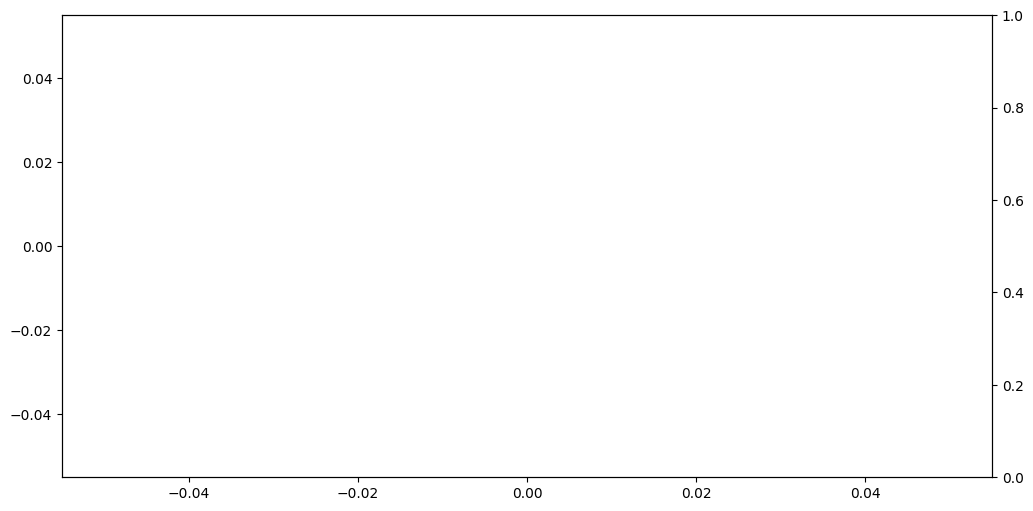

interactive(children=(IntSlider(value=0, description='sample_idx', max=99), IntSlider(value=0, description='an…

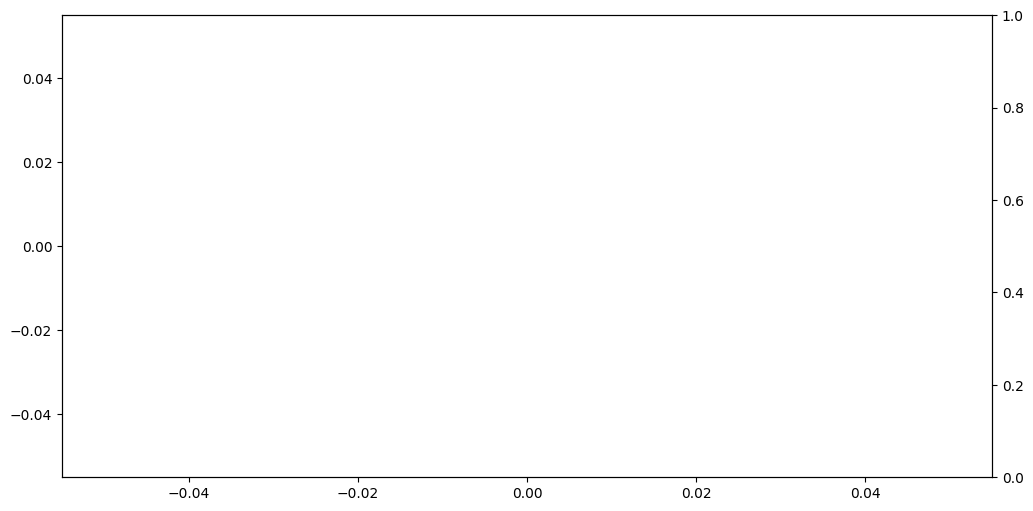

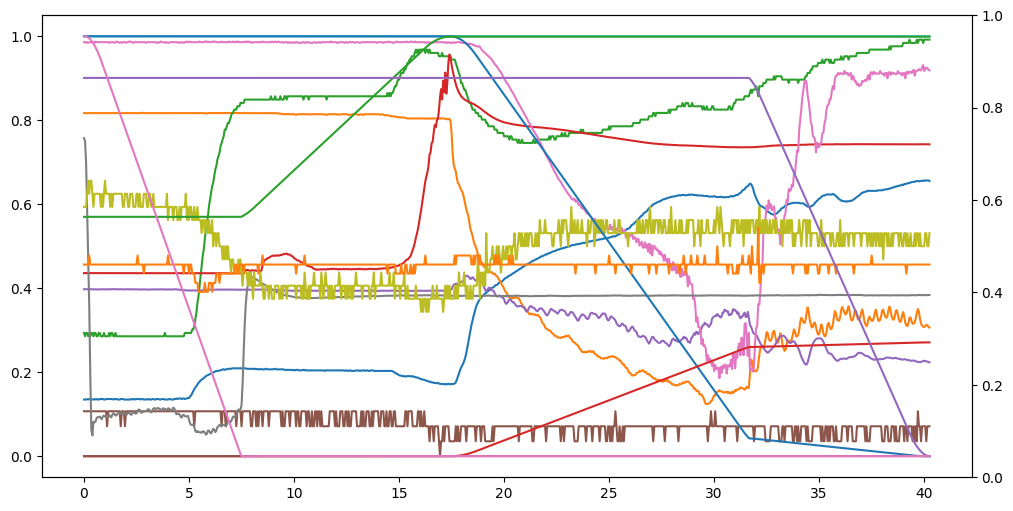

In [6]:
from utils.window_importance import WindowImportance

wi = WindowImportance(X, Y, rf, X.shape[2])
wi.interactive_window_plot(sensors_df, target_df)